In [3]:
#import necessary libraries and define constants
import os
import glob
import collections
import functions as fn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import siren
from siren.SIREN_Controller import SIREN_Controller

plt.rcParams.update({"text.usetex": True,"font.family": "serif","axes.labelsize": 12,"font.size": 12, "legend.fontsize": 10, "xtick.labelsize": 8,  "ytick.labelsize": 8, })
mixings         = np.logspace(-1,-6,num=6)
mixings_norm    = [0.1,0.01,0.001,0.0001,0.00001,0.000001]
masses          = ["0001000","0002000","0003000","0004000","0005000","0006000","0007000","0008000","0009000","0010000","0020000","0030000","0040000","0050000","0060000","0070000","0080000","0090000"]
seconds         = 10.67*365.25*24*3600 #seconds in 10.67 years
experiment      = "IceCube"
controller      = SIREN_Controller(1, experiment)
icecube_geo     = controller.fid_vol
atmosnumu       = fn.get_file_list(masses,mixings,deepcore=False,atmos=True,astro=False)
astronumu       = fn.get_file_list(masses,mixings,deepcore=False,atmos=False,astro=True)
dc_atmosnumu    = fn.get_file_list(masses,mixings,deepcore=True,atmos=True,astro=False)
dc_astronumu    = fn.get_file_list(masses,mixings,deepcore=True,atmos=False,astro=True)
sep_cuts        = list(range(4, 121, 4)) #in meters
ang_cuts        = list(range(1, 31, 1)) #in deg
L_cuts          = list(range(0,750, 25))#in meters
energy_threshold = 100
dc_energy_threshold = 10

In [4]:
print("IceCube Dictionaries")
atmosnumu_num_dimuons    = fn.make_num_dimuons_dict(atmosnumu,sep_cuts,ang_cuts,L_cuts,energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=False)
print("Atmos NuMu done")               
atmosnumubar_num_dimuons = fn.make_num_dimuons_dict(atmosnumu,sep_cuts,ang_cuts,L_cuts,energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=True)
print("Atmos NuMuBar done")
astronumu_num_dimuons    = fn.make_num_dimuons_dict(astronumu,sep_cuts,ang_cuts,L_cuts,energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=False)
print("Astro NuMu done")
astronumubar_num_dimuons = fn.make_num_dimuons_dict(astronumu,sep_cuts,ang_cuts,L_cuts,energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=True)
print("Astro NuMuBar done")
print("DeepCore Dictionaries")
dc_atmosnumu_num_dimuons    = fn.make_num_dimuons_dict(dc_atmosnumu,sep_cuts,ang_cuts,L_cuts,dc_energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=False)
print("Atmos NuMu done")
dc_atmosnumubar_num_dimuons = fn.make_num_dimuons_dict(dc_atmosnumu,sep_cuts,ang_cuts,L_cuts,dc_energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=True)
print("Atmos NuMuBar done")
dc_astronumu_num_dimuons    = fn.make_num_dimuons_dict(dc_astronumu,sep_cuts,ang_cuts,L_cuts,dc_energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=False)
print("Astro NuMu done")
dc_astronumubar_num_dimuons = fn.make_num_dimuons_dict(dc_astronumu,sep_cuts,ang_cuts,L_cuts,dc_energy_threshold,masses,mixings,mixings_norm,seconds,xs_ratio_weight=True)
print("Astro NuMuBar done")

IceCube Dictionaries
Atmos NuMu done
Atmos NuMuBar done
Astro NuMu done
Astro NuMuBar done
DeepCore Dictionaries
Atmos NuMu done
Atmos NuMuBar done
Astro NuMu done
Astro NuMuBar done


In [3]:
import math
def sep_s_over_b_lines_grid(dict1, dict2, dict3, dict4, dict1a, dict2a, dict3a, dict4a, sep_cuts, ylims):
    dicts = [dict1, dict2, dict3, dict4]  # Non-DeepCore
    dictsa = [dict1a, dict2a, dict3a, dict4a]  # DeepCore
    dict_colors = ['blue', 'green', 'red', 'orange'] 
    dict_colorsa = ['#aec7e8', '#98df8a', '#ff9896', '#ffbb78']  # Pastel colors
    dict_labels = [r"Atmos $\nu_\mu$", r"Atmos $\bar{\nu_\mu}$", r"Astro $\nu_\mu$", r"Astro $\bar{\nu_\mu}$"]
    num_cuts = len(sep_cuts)
    ncols = min(4, num_cuts)
    nrows = math.ceil(num_cuts / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if nrows > 1 or ncols > 1 else [axes]
    for idx, sep_cut in enumerate(sep_cuts):
        ax = axes[idx]
        for dict_index, dictionary in enumerate(dicts):
            dictionary_sorted = collections.OrderedDict(sorted(dictionary.items()))
            points = np.array(list(dictionary_sorted.keys()))
            vals_list = list(dictionary_sorted.values())
            sep_vals = {d: [v['sep'][d] for v in vals_list if 'sep' in v] for d in [sep_cut]}
            mpoints = np.unique(points[:, 0])
            Upoints = np.unique(points[:, 1])
            if sep_cut in sep_vals:
                sep_array = np.array(sep_vals[sep_cut]).reshape(len(mpoints), len(Upoints))
                ax.contour(mpoints, Upoints, sep_array.T, levels=[1, 11, 110], linestyles=[":", "--", "-"], colors=dict_colors[dict_index])
        for dict_index, dictionary in enumerate(dictsa):
            dictionary_sorted = collections.OrderedDict(sorted(dictionary.items()))
            points = np.array(list(dictionary_sorted.keys()))
            vals_list = list(dictionary_sorted.values())
            sep_vals = {d: [v['sep'][d] for v in vals_list if 'sep' in v] for d in [sep_cut]}
            mpoints = np.unique(points[:, 0])
            Upoints = np.unique(points[:, 1])
            if sep_cut in sep_vals:
                sep_array = np.array(sep_vals[sep_cut]).reshape(len(mpoints), len(Upoints))
                ax.contour(mpoints, Upoints, sep_array.T, levels=[1, 11, 110], linestyles=[":", "--", "-"], colors=dict_colorsa[dict_index])
        ax.set_xlim([min(mpoints), max(mpoints)])
        ax.set_ylim(ylims[0], ylims[1])
        ax.set_title(f"S = {sep_cut} m")
        ax.set_xlabel("HNL Mass [GeV]", fontsize=10)
        ax.set_ylabel(r"$|U_{\mu 4}|^2$", fontsize=10)
        #ax.text(1.1,1.5e-7,r"$E_\mu$ $>$ %d GeV"%10,fontsize=12)
        ax.loglog()
    for ax in axes[num_cuts:]:
        ax.axis('off')
    plt.tight_layout()
    lines_main    = [plt.Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(dict_colors, dict_labels)]
    legend1       = fig.legend(handles=lines_main, loc='lower left', bbox_to_anchor=(0.09, -0), fontsize=12, frameon=True, ncol=len(dict_labels))
    lines_legend2 = [plt.Line2D([0], [0], ls=":", color="black", label=r"$S/\sqrt{B} = 0.1$"),plt.Line2D([0], [0], ls="--", color="black", label=r"$S/\sqrt{B} = 1$"),plt.Line2D([0], [0], ls="-", color="black", label=r"$S/\sqrt{B} = 10$")]
    legend2       = fig.legend(handles=lines_legend2, loc='lower center', bbox_to_anchor=(0.59, -0), fontsize=12, frameon=True, ncol=len(lines_legend2))
    lines_legend3 = [plt.Line2D([0], [0], color=dict_colors[0], lw=2, label="IceCube"),plt.Line2D([0], [0], color=dict_colorsa[0], lw=2, label="DeepCore")]
    legend3       = fig.legend(handles=lines_legend3, loc='lower right', bbox_to_anchor=(0.91, -0), fontsize=12, frameon=True, ncol=len(lines_legend3))
    fig.add_artist(legend1)
    fig.add_artist(legend2)
    fig.add_artist(legend3)
    plt.subplots_adjust(bottom=0.15)
    #plt.savefig("/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/pcastanobasurto/IceCube_Dimuon/march17sims/sensitivities_separation.png")
    plt.show()

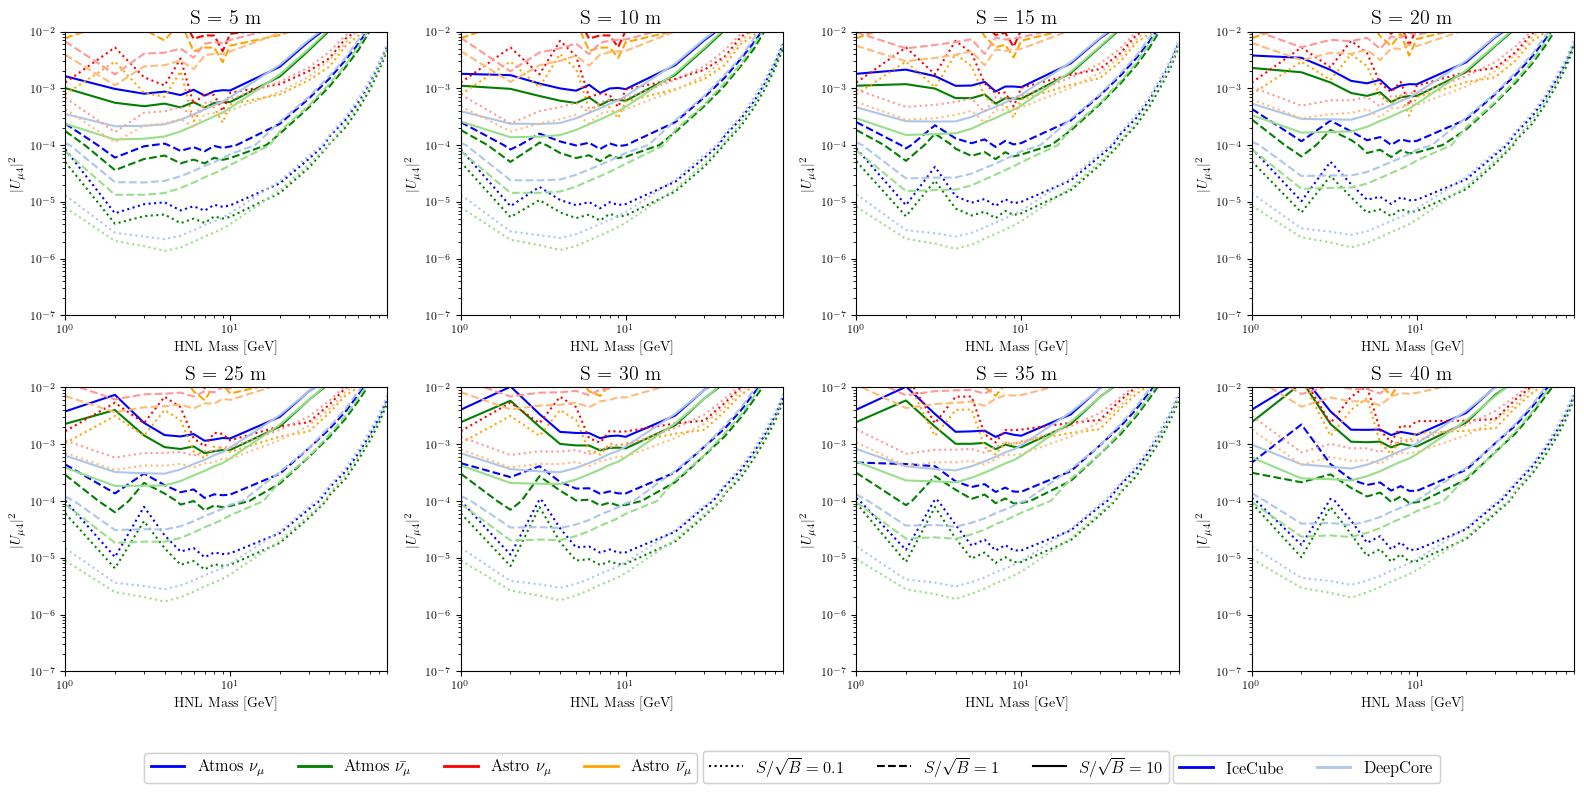

In [4]:
sep_s_over_b_lines_grid(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,sep_cuts,[1e-7,1e-2])


In [5]:
import math
def ang_s_over_b_lines_grid(dict1, dict2, dict3, dict4, dict1a, dict2a, dict3a, dict4a, ang_cuts, ylims):
    dicts = [dict1, dict2, dict3, dict4]  # Non-DeepCore
    dictsa = [dict1a, dict2a, dict3a, dict4a]  # DeepCore
    dict_colors = ['blue', 'green', 'red', 'orange'] 
    dict_colorsa = ['#aec7e8', '#98df8a', '#ff9896', '#ffbb78']  # Pastel colors
    dict_labels = [r"Atmos $\nu_\mu$", r"Atmos $\bar{\nu_\mu}$", r"Astro $\nu_\mu$", r"Astro $\bar{\nu_\mu}$"]
    num_cuts = len(ang_cuts)
    ncols = min(4, num_cuts)
    nrows = math.ceil(num_cuts / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if nrows > 1 or ncols > 1 else [axes]
    for idx, ang_cut in enumerate(ang_cuts):
        ax = axes[idx]
        for dict_index, dictionary in enumerate(dicts):
            dictionary_sorted = collections.OrderedDict(sorted(dictionary.items()))
            points = np.array(list(dictionary_sorted.keys()))
            vals_list = list(dictionary_sorted.values())
            ang_vals = {d: [v['ang'][d] for v in vals_list if 'ang' in v] for d in [ang_cut]}
            mpoints = np.unique(points[:, 0])
            Upoints = np.unique(points[:, 1])
            if ang_cut in ang_vals:
                ang_array = np.array(ang_vals[ang_cut]).reshape(len(mpoints), len(Upoints))
                ax.contour(mpoints, Upoints, ang_array.T, levels=[1, 11, 110], linestyles=[":", "--", "-"], colors=dict_colors[dict_index])
        for dict_index, dictionary in enumerate(dictsa):
            dictionary_sorted = collections.OrderedDict(sorted(dictionary.items()))
            points = np.array(list(dictionary_sorted.keys()))
            vals_list = list(dictionary_sorted.values())
            ang_vals = {d: [v['ang'][d] for v in vals_list if 'ang' in v] for d in [ang_cut]}
            mpoints = np.unique(points[:, 0])
            Upoints = np.unique(points[:, 1])
            if ang_cut in ang_vals:
                ang_array = np.array(ang_vals[ang_cut]).reshape(len(mpoints), len(Upoints))
                ax.contour(mpoints, Upoints, ang_array.T, levels=[1, 11, 110], linestyles=[":", "--", "-"], colors=dict_colorsa[dict_index])
        ax.set_xlim([min(mpoints), max(mpoints)])
        ax.set_ylim(ylims[0], ylims[1])
        ax.set_title(r"$\theta$ $=$ %d deg"%ang_cut)
        ax.set_xlabel("HNL Mass [GeV]", fontsize=10)
        ax.set_ylabel(r"$|U_{\mu 4}|^2$", fontsize=10)
        #ax.text(1.1,1.5e-7,r"$E_\mu$ $>$ %d GeV"%10,fontsize=12)
        ax.loglog()
    for ax in axes[num_cuts:]:
        ax.axis('off')
    plt.tight_layout()
    lines_main    = [plt.Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(dict_colors, dict_labels)]
    legend1       = fig.legend(handles=lines_main, loc='lower left', bbox_to_anchor=(0.09, -0), fontsize=12, frameon=True, ncol=len(dict_labels))
    lines_legend2 = [plt.Line2D([0], [0], ls=":", color="black", label=r"$S/\sqrt{B} = 0.1$"),plt.Line2D([0], [0], ls="--", color="black", label=r"$S/\sqrt{B} = 1$"),plt.Line2D([0], [0], ls="-", color="black", label=r"$S/\sqrt{B} = 10$")]
    legend2       = fig.legend(handles=lines_legend2, loc='lower center', bbox_to_anchor=(0.59, -0), fontsize=12, frameon=True, ncol=len(lines_legend2))
    lines_legend3 = [plt.Line2D([0], [0], color=dict_colors[0], lw=2, label="IceCube"),plt.Line2D([0], [0], color=dict_colorsa[0], lw=2, label="DeepCore")]
    legend3       = fig.legend(handles=lines_legend3, loc='lower right', bbox_to_anchor=(0.91, -0), fontsize=12, frameon=True, ncol=len(lines_legend3))
    fig.add_artist(legend1)
    fig.add_artist(legend2)
    fig.add_artist(legend3)
    plt.subplots_adjust(bottom=0.15)
    #plt.savefig("/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/pcastanobasurto/IceCube_Dimuon/march17sims/sensitivities_angle.png")
    plt.show()

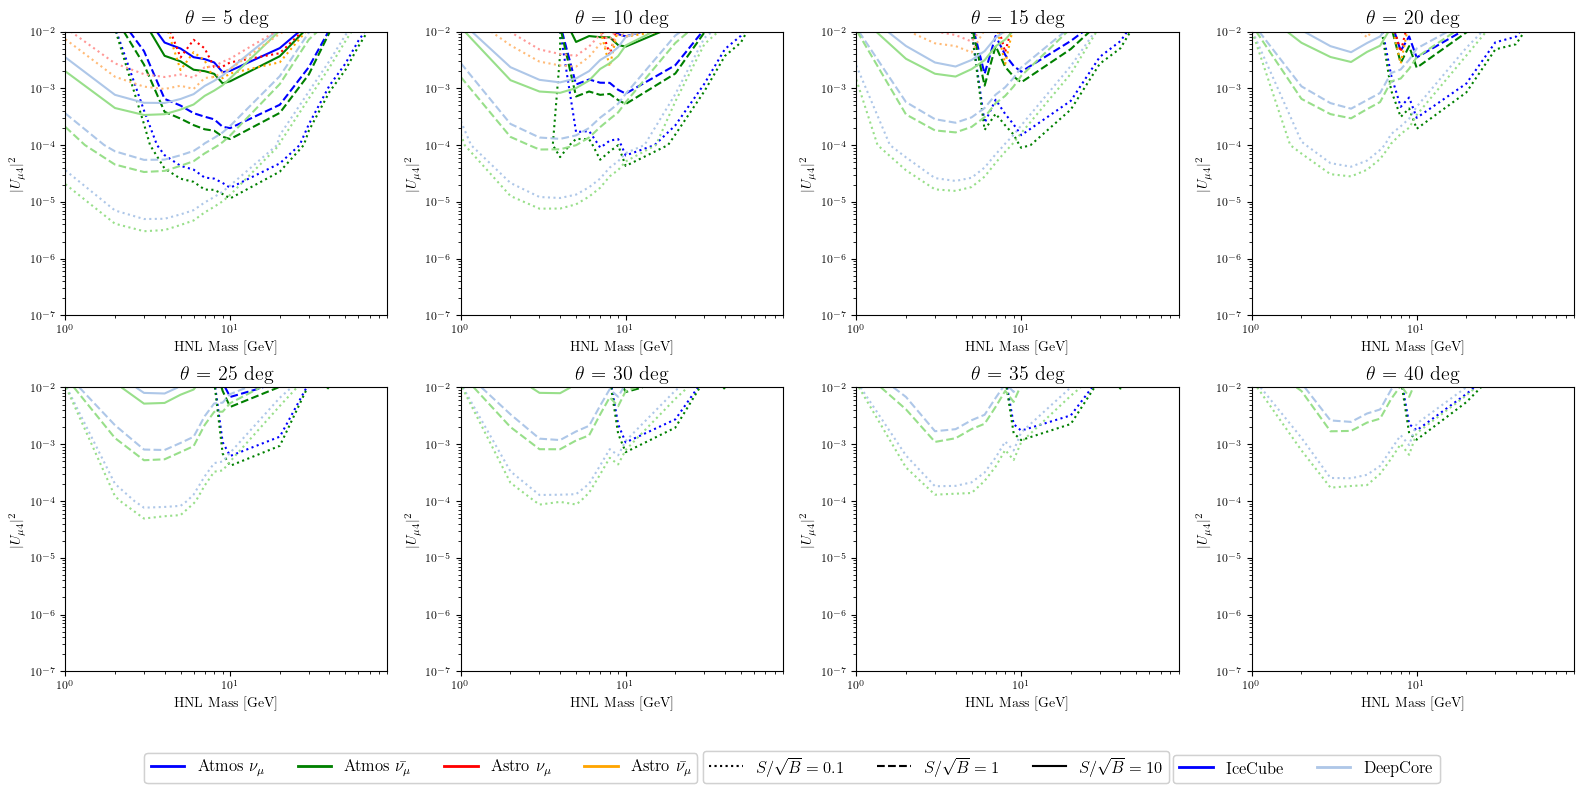

In [6]:
ang_s_over_b_lines_grid(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,ang_cuts,[1e-7,1e-2])


In [7]:
import math
def dis_s_over_b_lines_grid(dict1, dict2, dict3, dict4, dict1a, dict2a, dict3a, dict4a, L_cuts, ylims):
    dicts = [dict1, dict2, dict3, dict4]  # Non-DeepCore
    dictsa = [dict1a, dict2a, dict3a, dict4a]  # DeepCore
    dict_colors = ['blue', 'green', 'red', 'orange'] 
    dict_colorsa = ['#aec7e8', '#98df8a', '#ff9896', '#ffbb78']  # Pastel colors
    dict_labels = [r"Atmos $\nu_\mu$", r"Atmos $\bar{\nu_\mu}$", r"Astro $\nu_\mu$", r"Astro $\bar{\nu_\mu}$"]
    num_cuts = len(L_cuts)
    ncols = min(4, num_cuts)
    nrows = math.ceil(num_cuts / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten() if nrows > 1 or ncols > 1 else [axes]
    for idx, L_cut in enumerate(L_cuts):
        ax = axes[idx]
        for dict_index, dictionary in enumerate(dicts):
            dictionary_sorted = collections.OrderedDict(sorted(dictionary.items()))
            points = np.array(list(dictionary_sorted.keys()))
            vals_list = list(dictionary_sorted.values())
            L_vals = {d: [v['dis'][d] for v in vals_list if 'dis' in v] for d in [L_cut]}
            mpoints = np.unique(points[:, 0])
            Upoints = np.unique(points[:, 1])
            if L_cut in L_vals:
                L_array = np.array(L_vals[L_cut]).reshape(len(mpoints), len(Upoints))
                ax.contour(mpoints, Upoints, L_array.T, levels=[1, 11, 110], linestyles=[":", "--", "-"], colors=dict_colors[dict_index])
        for dict_index, dictionary in enumerate(dictsa):
            dictionary_sorted = collections.OrderedDict(sorted(dictionary.items()))
            points = np.array(list(dictionary_sorted.keys()))
            vals_list = list(dictionary_sorted.values())
            L_vals = {d: [v['dis'][d] for v in vals_list if 'dis' in v] for d in [L_cut]}
            mpoints = np.unique(points[:, 0])
            Upoints = np.unique(points[:, 1])
            if L_cut in L_vals:
                L_array = np.array(L_vals[L_cut]).reshape(len(mpoints), len(Upoints))
                ax.contour(mpoints, Upoints, L_array.T, levels=[1, 11, 110], linestyles=[":", "--", "-"], colors=dict_colorsa[dict_index])
        ax.set_xlim([min(mpoints), max(mpoints)])
        ax.set_ylim(ylims[0], ylims[1])
        ax.set_title(f"L = {L_cut} m")
        ax.set_xlabel("HNL Mass [GeV]", fontsize=10)
        ax.set_ylabel(r"$|U_{\mu 4}|^2$", fontsize=10)
        #ax.text(1.1,1.5e-7,r"$E_\mu$ $>$ %d GeV"%10,fontsize=12)
        ax.loglog()
    for ax in axes[num_cuts:]:
        ax.axis('off')
    plt.tight_layout()
    lines_main    = [plt.Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(dict_colors, dict_labels)]
    legend1       = fig.legend(handles=lines_main, loc='lower left', bbox_to_anchor=(0.09, -0), fontsize=12, frameon=True, ncol=len(dict_labels))
    lines_legend2 = [plt.Line2D([0], [0], ls=":", color="black", label=r"$S/\sqrt{B} = 0.1$"),plt.Line2D([0], [0], ls="--", color="black", label=r"$S/\sqrt{B} = 1$"),plt.Line2D([0], [0], ls="-", color="black", label=r"$S/\sqrt{B} = 10$")]
    legend2       = fig.legend(handles=lines_legend2, loc='lower center', bbox_to_anchor=(0.59, -0), fontsize=12, frameon=True, ncol=len(lines_legend2))
    lines_legend3 = [plt.Line2D([0], [0], color=dict_colors[0], lw=2, label="IceCube"),plt.Line2D([0], [0], color=dict_colorsa[0], lw=2, label="DeepCore")]
    legend3       = fig.legend(handles=lines_legend3, loc='lower right', bbox_to_anchor=(0.91, -0), fontsize=12, frameon=True, ncol=len(lines_legend3))
    fig.add_artist(legend1)
    fig.add_artist(legend2)
    fig.add_artist(legend3)
    plt.subplots_adjust(bottom=0.15)
    #plt.savefig("/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/pcastanobasurto/IceCube_Dimuon/march17sims/sensitivities_angle.png")
    plt.show()

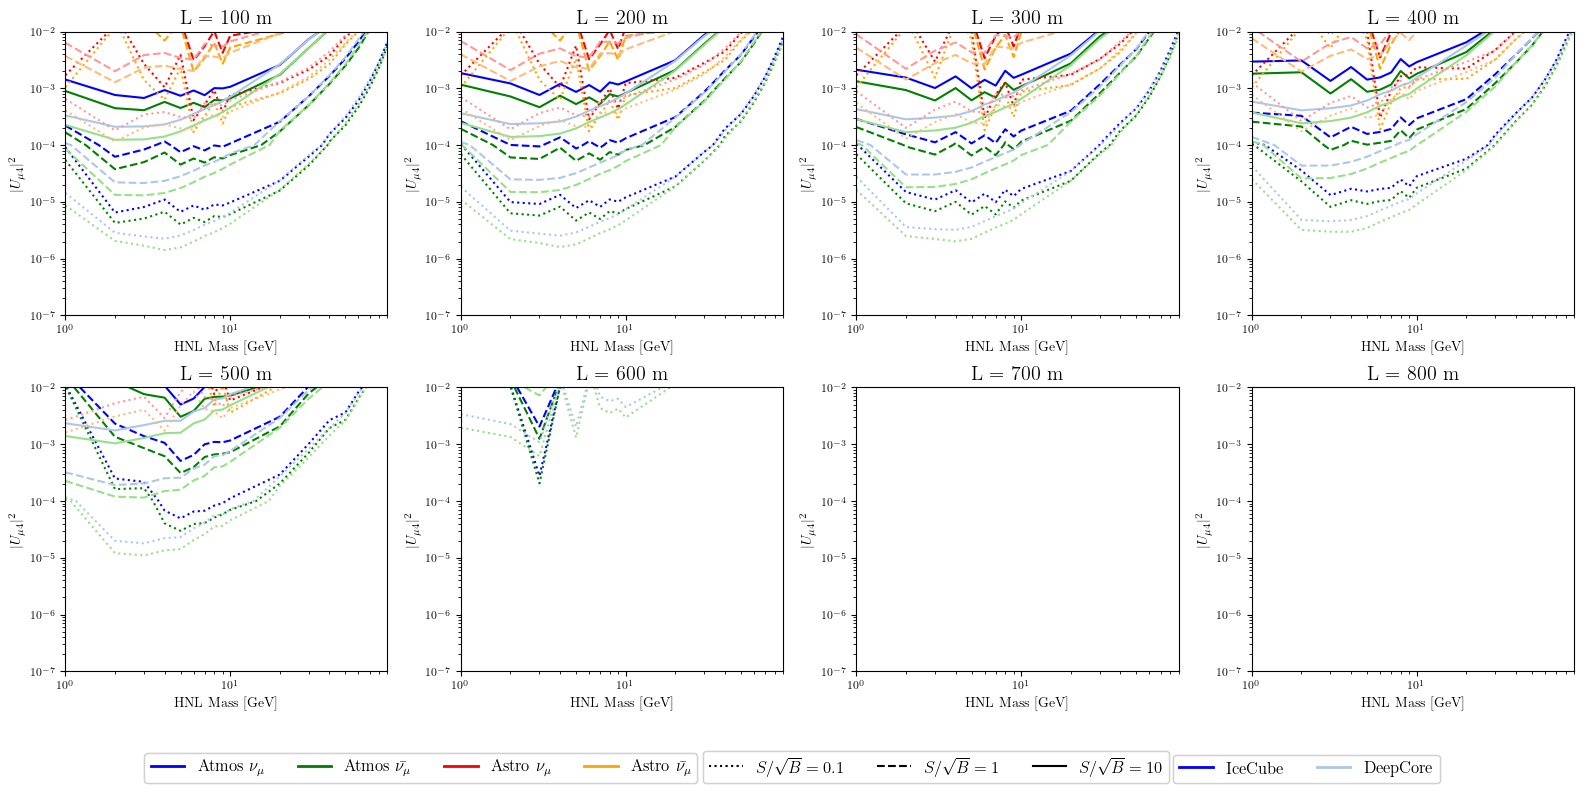

In [8]:
dis_s_over_b_lines_grid(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,L_cuts,[1e-7,1e-2])


In [85]:
#now we make a heatmap with the event rate for S_max, L_min, and Theta for IceCube atmos events
from matplotlib.colors import LogNorm
def make_event_rate_heatmap(dict1,dict2,dict3,dict4,dict1a,dict2a,dict3a,dict4a,mass,mixing,sep_cuts,ang_cuts,L_cuts,S_max,L_min,Theta):
    if S_max and L_min and not Theta:
        L_min_values = []
        S_max_values = []
        event_rates  = []
        for i in L_cuts:
            for j in sep_cuts:
                #weight = dict1[(mass, mixing)]["dis"].get(i, 0)*dict1[(mass, mixing)]["sep"].get(j, 0)+dict2[(mass, mixing)]["dis"].get(i, 0)*dict2[(mass, mixing)]["sep"].get(j, 0)+dict3[(mass, mixing)]["dis"].get(i, 0)*dict3[(mass, mixing)]["sep"].get(j, 0)+dict4[(mass, mixing)]["dis"].get(i, 0)*dict4[(mass, mixing)]["sep"].get(j, 0)+dict1a[(mass, mixing)]["dis"].get(i, 0)*dict1a[(mass, mixing)]["sep"].get(j, 0)+dict2a[(mass, mixing)]["dis"].get(i, 0)*dict2a[(mass, mixing)]["sep"].get(j, 0)+dict3a[(mass, mixing)]["dis"].get(i, 0)*dict3a[(mass, mixing)]["sep"].get(j, 0)+dict4a[(mass, mixing)]["dis"].get(i, 0)*dict4a[(mass, mixing)]["sep"].get(j, 0)
                weight = dict1[(mass, mixing)]["dis"].get(i, 0) + dict1[(mass, mixing)]["sep"].get(j, 0)
                if weight>0:
                    L_min_values.append(i)
                    S_max_values.append(j)
                    event_rates.append(weight)
        L_min_values = np.array(L_min_values)
        S_max_values = np.array(S_max_values)
        event_rates  = np.array(event_rates)
        L_min_grid, S_max_grid = np.meshgrid(np.sort(np.unique(L_min_values)), np.sort(np.unique(S_max_values)))
        event_rate_grid = np.zeros_like(L_min_grid, dtype=np.float64)
        for elem in range(len(L_min_values)):
            L_idx = np.where(L_min_grid[0] == L_min_values[elem])[0][0]
            S_idx = np.where(S_max_grid[:,0] == S_max_values[elem])[0][0]
            event_rate_grid[S_idx, L_idx] = event_rates[elem]
        plt.figure(figsize=(10, 8))
        plt.pcolor(L_min_grid, 
                   S_max_grid, 
                   event_rate_grid, 
                   #shading='auto', 
                   norm=LogNorm(1e0, vmax=event_rate_grid.max()), 
                   cmap='viridis')
        plt.colorbar(label="Event Rate (Weighted)")
        plt.xlabel('L_min [m]')
        plt.ylabel('S_max [m]')
        plt.title(f'Event Rates for {mass,np.sqrt(mixing)}')
        plt.show()
    elif S_max and Theta and not L_min:
        S_max_values = []
        Theta_values = []
        event_rates  = []
        for i in sep_cuts:
            for j in ang_cuts:
                weight = dict1[(mass, mixing)]["sep"].get(i, 0)*dict1[(mass, mixing)]["ang"].get(j, 0)+dict2[(mass, mixing)]["sep"].get(i, 0)*dict2[(mass, mixing)]["ang"].get(j, 0)+dict3[(mass, mixing)]["sep"].get(i, 0)*dict3[(mass, mixing)]["ang"].get(j, 0)+dict4[(mass, mixing)]["sep"].get(i, 0)*dict4[(mass, mixing)]["ang"].get(j, 0)+dict1a[(mass, mixing)]["sep"].get(i, 0)*dict1a[(mass, mixing)]["ang"].get(j, 0)+dict2a[(mass, mixing)]["sep"].get(i, 0)*dict2a[(mass, mixing)]["ang"].get(j, 0)+dict3a[(mass, mixing)]["sep"].get(i, 0)*dict3a[(mass, mixing)]["ang"].get(j, 0)+dict4a[(mass, mixing)]["sep"].get(i, 0)*dict4a[(mass, mixing)]["ang"].get(j, 0)
                if weight > 0:
                    S_max_values.append(i)
                    Theta_values.append(j)
                    event_rates.append(weight)
        S_max_values = np.array(S_max_values)
        Theta_values = np.array(Theta_values)
        event_rates  = np.array(event_rates)   
        Theta_grid, S_max_grid = np.meshgrid(np.sort(np.unique(Theta_values)), np.sort(np.unique(S_max_values)))
        event_rate_grid = np.zeros_like(Theta_grid, dtype=np.float64)
        for elem in range(len(Theta_values)):
            T_idx = np.where(Theta_grid[0] == Theta_values[elem])[0][0]
            S_idx = np.where(S_max_grid[:,0] == S_max_values[elem])[0][0]
            event_rate_grid[S_idx, T_idx] = event_rates[elem]
        plt.figure(figsize=(10, 8))
        plt.pcolor(Theta_grid, S_max_grid, event_rate_grid, shading='auto', norm=LogNorm(vmin=1e6, vmax=event_rate_grid.max()))
        plt.colorbar(label='Event Rate (Weighted)')
        plt.xlabel('Theta [deg]')
        plt.ylabel('S_max [m]')
        plt.title(f'Event Rates for {mass,np.sqrt(mixing)}')
        plt.show()
    elif Theta and L_min and not S_max: 
        L_min_values = []
        Theta_values = []
        event_rates  = []
        for i in L_cuts:
            for j in ang_cuts:
                weight = dict1[(mass, mixing)]["dis"].get(i, 0)*dict1[(mass, mixing)]["ang"].get(j, 0)+dict2[(mass, mixing)]["dis"].get(i, 0)*dict2[(mass, mixing)]["ang"].get(j, 0)+dict3[(mass, mixing)]["dis"].get(i, 0)*dict3[(mass, mixing)]["ang"].get(j, 0)+dict4[(mass, mixing)]["dis"].get(i, 0)*dict4[(mass, mixing)]["ang"].get(j, 0)+dict1a[(mass, mixing)]["dis"].get(i, 0)*dict1a[(mass, mixing)]["ang"].get(j, 0)+dict2a[(mass, mixing)]["dis"].get(i, 0)*dict2a[(mass, mixing)]["ang"].get(j, 0)+dict3a[(mass, mixing)]["dis"].get(i, 0)*dict3a[(mass, mixing)]["ang"].get(j, 0)+dict4a[(mass, mixing)]["dis"].get(i, 0)*dict4a[(mass, mixing)]["ang"].get(j, 0)
                if weight>0:
                    L_min_values.append(i)
                    Theta_values.append(j)
                    event_rates.append(weight)
        L_min_values = np.array(L_min_values)
        Theta_values = np.array(Theta_values)
        event_rates  = np.array(event_rates)   
        Theta_grid, L_min_grid = np.meshgrid(np.sort(np.unique(Theta_values)), np.sort(np.unique(L_min_values)))
        event_rate_grid = np.zeros_like(Theta_grid, dtype=np.float64)
        for elem in range(len(Theta_values)):
            T_idx = np.where(Theta_grid[0] == Theta_values[elem])[0][0]
            L_idx = np.where(L_min_grid[:,0] == L_min_values[elem])[0][0]
            event_rate_grid[L_idx, T_idx] = event_rates[elem]
        plt.figure(figsize=(10, 8))
        plt.pcolor(Theta_grid, L_min_grid, event_rate_grid, shading='auto', norm=LogNorm(vmin=1e6, vmax=event_rate_grid.max()))
        plt.colorbar(label='Event Rate (Weighted)')
        plt.xlabel('Theta [deg]')
        plt.ylabel('L_min [m]')
        plt.title(f'Event Rates for {mass,np.sqrt(mixing)}')
        plt.show()

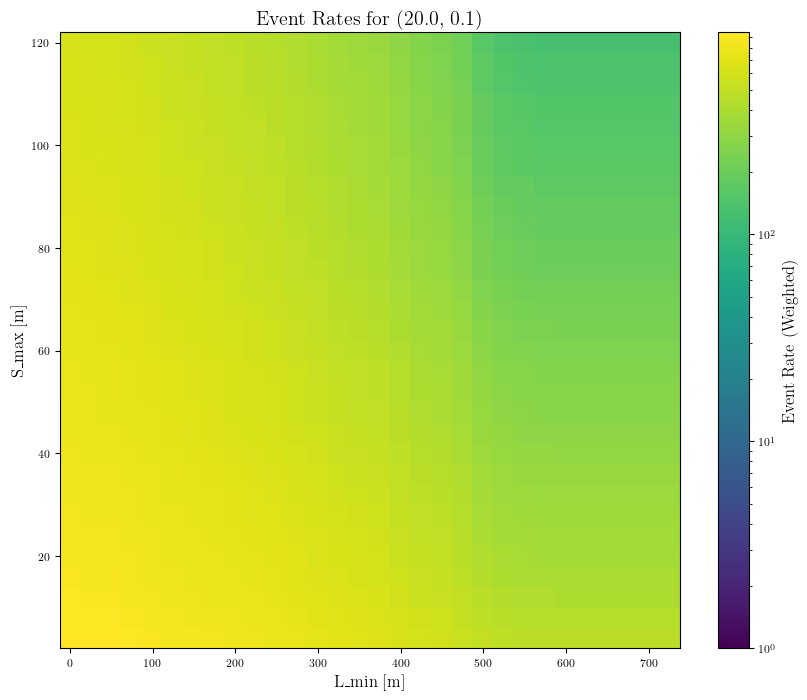

In [87]:
key_list = list(atmosnumu_num_dimuons.keys())
mass,mixing = key_list[60]
make_event_rate_heatmap(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,mass,mixing,sep_cuts,ang_cuts,L_cuts,S_max=True,L_min=True,Theta=False)
#make_event_rate_heatmap(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,mass,mixing,sep_cuts,ang_cuts,L_cuts,S_max=True,L_min=False,Theta=True)
#make_event_rate_heatmap(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,mass,mixing,sep_cuts,ang_cuts,L_cuts,S_max=False,L_min=True,Theta=True)
#for (mass,mixing) in (key_list[24],key_list[54],key_list[60],key_list[78],key_list[102]):
#   make_event_rate_heatmap(atmosnumu_num_dimuons,atmosnumubar_num_dimuons,astronumu_num_dimuons,astronumubar_num_dimuons,dc_atmosnumu_num_dimuons,dc_atmosnumubar_num_dimuons,dc_astronumu_num_dimuons,dc_astronumubar_num_dimuons,mass,mixing,sep_cuts,ang_cuts,L_cuts,S_max=True,L_min=True,Theta=False)

